<a href="https://colab.research.google.com/github/komalprashar790-cmyk/Machine-Learning-model/blob/main/machine_learning_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

original dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26   

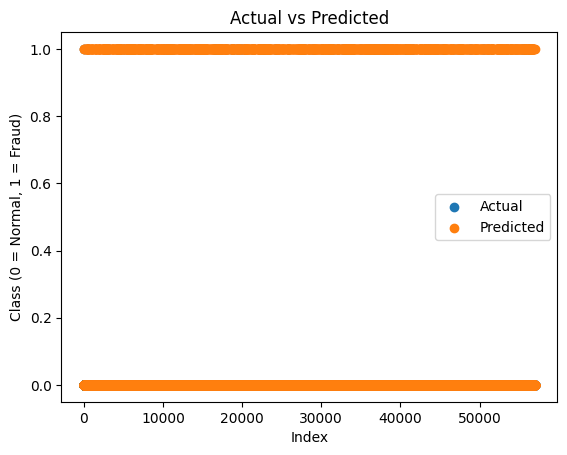

Confusion Matrix:
[[55528  1336]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



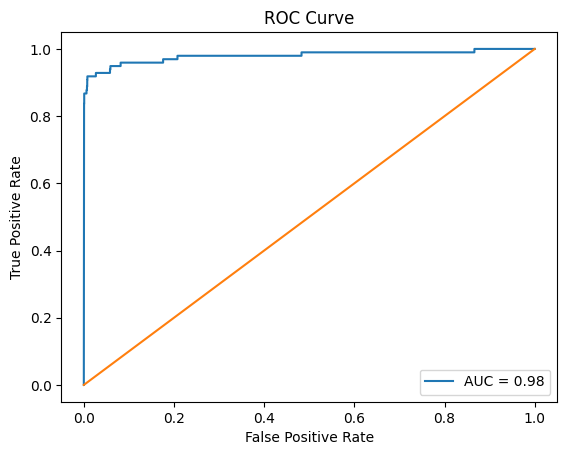

In [ ]:
#step1 : importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# step 2: upload dataset
data = pd.read_csv("/content/creditcard.csv")
print("original dataset:")
print(data.head())

data.dropna(subset=['Class'], inplace=True)
x = data.drop("Class",axis=1)
y= data["Class"]

# clean the data
from sklearn.impute import SimpleImputer

# fill missing numercial values with mean:
imputer = SimpleImputer(strategy="mean")
x_imputed = imputer.fit_transform(x)

# train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_imputed,y,test_size=0.2,random_state=42)

#after splits the features scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
#train model:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced",max_iter=2000)
model.fit(x_train,y_train)

#prediction:
y_pred = model.predict(x_test)

# visualization:
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.xlabel("Index")
plt.ylabel("Class (0 = Normal, 1 = Fraud)")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

#Evaluation
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# STEP 10: ROC Curve
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1])             # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()